# Land Availability — Verification & Visualization

**Purpose:** sanity-check the Google Earth Engine land-cover pull
(`land_availability/gee_facility_calculate_available_area.py`) before it constrains the
flatblock optimization.

For each facility we buffer its point (**5 km** baseline, 15 km sensitivity), mask out
slope > 5° and WDPA protected areas, and sum ESA WorldCover area by land-cover class.
`available_land_km2` = **bare_sparse + cropland + grassland + shrubland** — the open,
developable land suitable for colocated solar (forest, built-up, water, wetland are excluded).

We verify:

1. **Completeness** — every facility has land data; buffer areas are physically bounded.
2. **Buffer coverage** — classified + masked area ≈ the 78.5 km² disc (π·5²).
3. **Composition** — developable vs excluded vs slope/protected-masked splits are sensible.
4. **Distribution** — available land and developable share across the fleet.
5. **Subsector / country / geography** — patterns look reasonable.
6. **5 km vs 15 km** — the two buffers scale consistently (area ∝ r²).
7. **Land vs heat demand** — do the high-heat sites actually have land to work with?


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- paths -----------------------------------------------------------------
ROOT = Path.cwd()
while not (ROOT / "land_availability").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SITE = ROOT / "outputs" / "eu_ihb_site_assessment_2024.csv"          # land + subsector + heat
LAND15 = ROOT / "land_availability" / "outputs" / "land_availability_by_facility_15km.csv"

BUFFER_KM = 5.0
BUFFER_AREA = np.pi * BUFFER_KM**2   # 78.54 km2

# --- house style (mirrors the solar notebook) ------------------------------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.8,
    "axes.edgecolor": "#888888", "axes.linewidth": 0.8,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "axes.labelcolor": "#222222", "text.color": "#222222",
})
SEQ = "cividis"                                            # magnitude, colorblind-safe
OKABE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442"]
INK, MUTED = "#222222", "#666666"

DEVELOPABLE = ["bare_sparse_km2", "cropland_km2", "grassland_km2", "shrubland_km2"]
EXCLUDED = ["tree_cover_km2", "built_up_km2", "water_km2", "wetland_km2",
            "snow_ice_km2", "mangroves_km2", "moss_lichen_km2"]

df = pd.read_csv(SITE, low_memory=False)
# "runnable" = the study set (solar profile + positive replaceable heat)
run = df[df["has_solar_data"] & df["has_replaceable_heat"]].copy()
print(f"all facilities: {len(df):,}   runnable (solar+heat): {len(run):,}   "
      f"countries: {df['iso3_country'].nunique()}")
df[["subsector", "available_land_km2", "replaceable_heat_mwh_th"]].head()


all facilities: 2,415   runnable (solar+heat): 2,192   countries: 27


,subsector,available_land_km2,replaceable_heat_mwh_th
0,food-beverage-tobacco,43.27,"415,349.83"
1,food-beverage-tobacco,36.45,"415,349.83"
2,chemicals,0.10,"286,371.87"
3,food-beverage-tobacco,36.42,"415,349.83"
4,glass,9.28,NaN


## 1. Completeness & data quality

Every facility should carry land data. `available_land_km2` and every class area must be non-negative and bounded by the 78.5 km² buffer disc. Flag facilities with **zero** developable land (urban / forest-locked sites the optimizer can't site solar at).

In [2]:
km2_cols = [c for c in df.columns if c.endswith("_km2")]
class_cols = [c for c in km2_cols if c != "available_land_km2"]

print(f"rows: {len(df):,}")
print(f"non-null available_land_km2 : {df['available_land_km2'].notna().sum():,}")
print(f"negative any class area     : {int((df[class_cols] < 0).any(axis=1).sum())}")
print(f"available_land > buffer area: {int((df['available_land_km2'] > BUFFER_AREA + 0.5).sum())}")

zero_land = df[df["available_land_km2"] == 0]
print(f"\nfacilities with ZERO developable land: {len(zero_land)}")
zero_land[["source_id", "source_name", "iso3_country", "subsector", "built_up_km2",
           "tree_cover_km2", "available_land_km2"]].head(12)


rows: 2,415
non-null available_land_km2 : 2,415
negative any class area     : 0
available_land > buffer area: 0

facilities with ZERO developable land: 26


,source_id,source_name,iso3_country,subsector,built_up_km2,tree_cover_km2,available_land_km2
22,38469146,Saint-Gobain Isover Austria Gmbh,AUT,glass,0.00,0.00,0.00
113,38478754,Bames Eood,BGR,textiles-leather-apparel,0.00,0.00,0.00
127,38475621,E Miroglio Ead Spinning And Dyeing Yambol,BGR,textiles-leather-apparel,0.00,0.00,0.00
135,38479419,Feshko Fashion Services Company Ood,BGR,textiles-leather-apparel,0.00,0.00,0.00
139,38479722,Izi Company Ltd,BGR,textiles-leather-apparel,0.00,0.00,0.00
268,44375507,"Dynos GmbH, Niederlassung Bad Durkheim",DEU,pulp-and-paper,0.00,0.00,0.00
605,38480922,"Manuel Romero Delgado, S.L.",ESP,food-beverage-tobacco,0.00,0.00,0.00
616,38481019,"Matadero La Jabugueña, S.L.",ESP,food-beverage-tobacco,0.00,0.00,0.00
617,38480910,Matadero Y Sala De Despiece De Cerdo Ibérico,ESP,food-beverage-tobacco,0.00,0.00,0.00
669,38480878,"Sánchez Romero Carvajal Jabugo, S.A.",ESP,food-beverage-tobacco,0.00,0.00,0.00


## 2. Buffer coverage — does the accounting close?

Classified land (all WorldCover classes) plus the slope/protected area masked out should sum to the 78.5 km² disc. Coastal/border sites fall a bit short (buffer over sea outside WorldCover). No facility should exceed the disc.

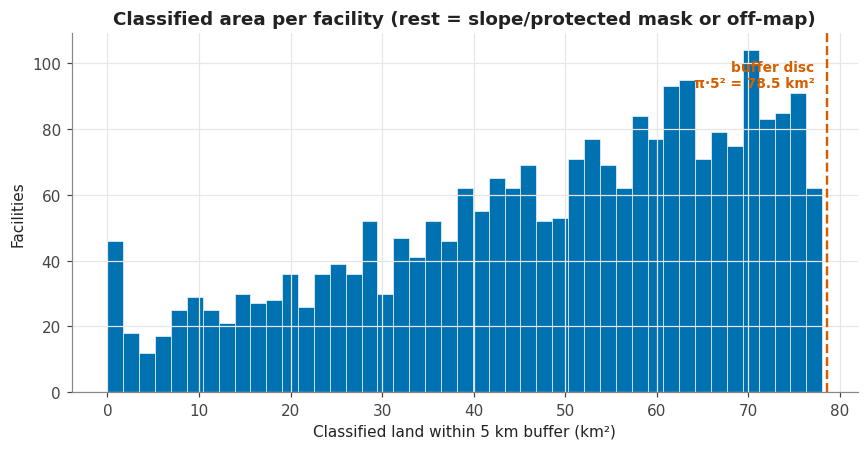

mean classified: 48.2 km²  (61% of disc)
mean masked/off-map: 30.3 km²
facilities exceeding disc: 0


In [3]:
df["classified_km2"] = df[class_cols].sum(axis=1)
df["masked_km2"] = (BUFFER_AREA - df["classified_km2"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(df["classified_km2"], bins=45, color="#0072B2", edgecolor="white", linewidth=0.4)
ax.axvline(BUFFER_AREA, color="#D55E00", ls="--", lw=1.6)
ax.annotate(f"buffer disc\nπ·5² = {BUFFER_AREA:.1f} km²", (BUFFER_AREA, ax.get_ylim()[1]*0.85),
            xytext=(-8, 0), textcoords="offset points", ha="right", color="#D55E00",
            fontsize=9, fontweight="bold")
ax.set_xlabel("Classified land within 5 km buffer (km²)"); ax.set_ylabel("Facilities")
ax.set_title("Classified area per facility (rest = slope/protected mask or off-map)")
plt.tight_layout(); plt.show()

print(f"mean classified: {df['classified_km2'].mean():.1f} km²  "
      f"({df['classified_km2'].mean()/BUFFER_AREA*100:.0f}% of disc)")
print(f"mean masked/off-map: {df['masked_km2'].mean():.1f} km²")
print(f"facilities exceeding disc: {int((df['classified_km2'] > BUFFER_AREA + 0.5).sum())}")


## 3. Fleet land composition

Where does the buffer land go? First the top-level split (developable / excluded land-cover / slope+protected mask), then the makeup of the developable share.

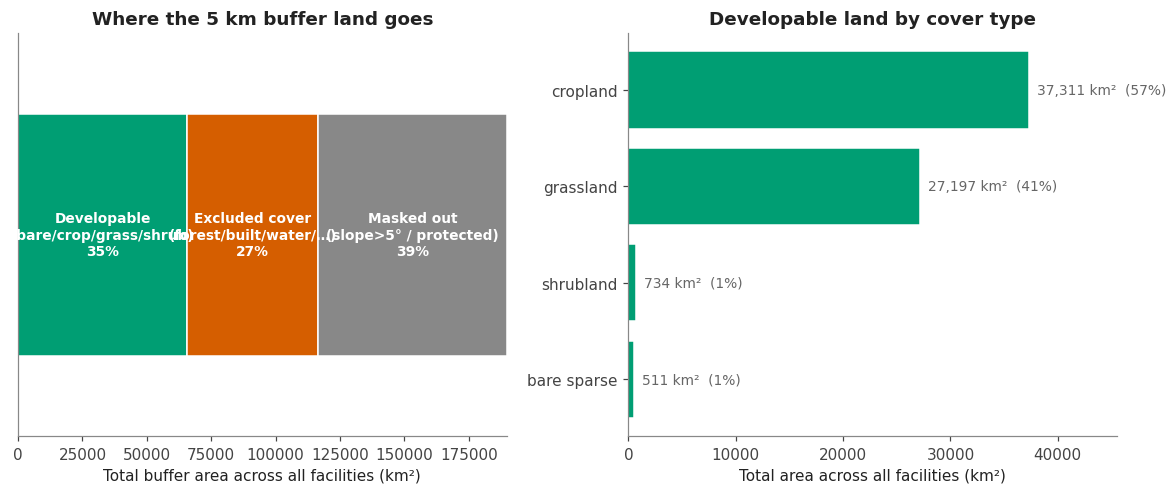

In [4]:
dev_tot = df[DEVELOPABLE].sum().sum()
exc_tot = df[EXCLUDED].sum().sum()
msk_tot = df["masked_km2"].sum()
grand = dev_tot + exc_tot + msk_tot

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# (a) top-level split — one stacked bar
parts = [("Developable\n(bare/crop/grass/shrub)", dev_tot, "#009E73"),
         ("Excluded cover\n(forest/built/water/…)", exc_tot, "#D55E00"),
         ("Masked out\n(slope>5° / protected)", msk_tot, "#888888")]
left = 0
for lab, val, col in parts:
    axes[0].barh(0, val, left=left, color=col, edgecolor="white", height=0.6)
    axes[0].annotate(f"{lab}\n{val/grand*100:.0f}%", (left + val/2, 0), ha="center", va="center",
                     color="white", fontsize=9, fontweight="bold")
    left += val
axes[0].set_xlim(0, grand); axes[0].set_ylim(-0.5, 0.5); axes[0].set_yticks([])
axes[0].set_xlabel("Total buffer area across all facilities (km²)")
axes[0].set_title("Where the 5 km buffer land goes")
axes[0].grid(False)

# (b) developable breakdown
dev = df[DEVELOPABLE].sum().sort_values(ascending=True)
labels = [c.replace("_km2", "").replace("_", " ") for c in dev.index]
axes[1].barh(labels, dev.values, color="#009E73", edgecolor="white")
for i, v in enumerate(dev.values):
    axes[1].annotate(f"{v:,.0f} km²  ({v/dev_tot*100:.0f}%)", (v, i), xytext=(5, 0),
                     textcoords="offset points", va="center", fontsize=9, color=MUTED)
axes[1].set_xlabel("Total area across all facilities (km²)")
axes[1].set_title("Developable land by cover type")
axes[1].margins(x=0.22); axes[1].grid(False)
plt.tight_layout(); plt.show()


## 4. Available land & developable-share distributions

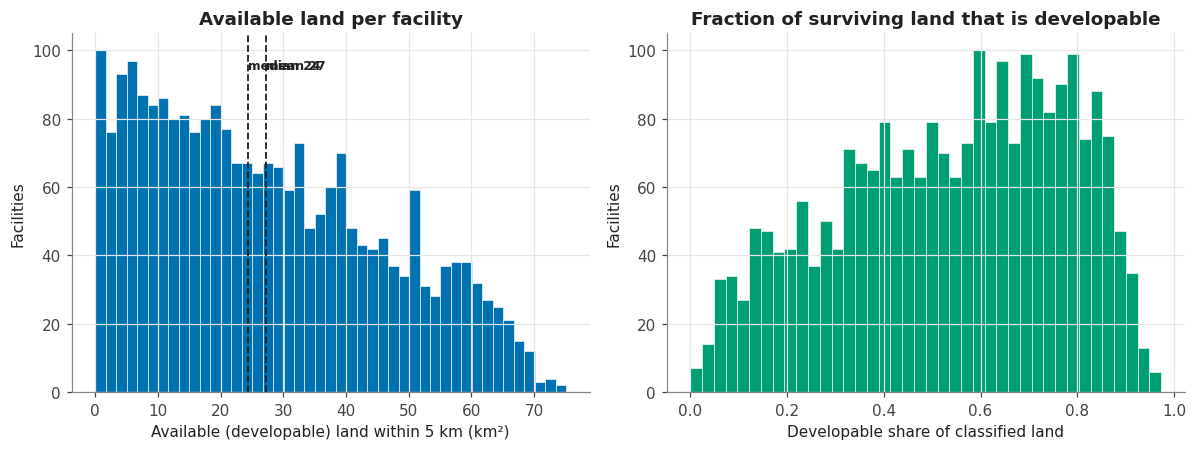

count   2,415.00
mean       27.23
std        18.62
min         0.00
25%        11.30
50%        24.38
75%        40.65
max        75.11


In [5]:
df["dev_share"] = df["available_land_km2"] / df["classified_km2"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(df["available_land_km2"], bins=45, color="#0072B2", edgecolor="white", linewidth=0.4)
for v, lab in [(df["available_land_km2"].median(), "median"), (df["available_land_km2"].mean(), "mean")]:
    axes[0].axvline(v, color=INK, ls="--", lw=1.2)
    axes[0].annotate(f"{lab} {v:,.0f}", (v, axes[0].get_ylim()[1]*0.9), ha="left",
                     fontsize=8, color=INK, fontweight="bold")
axes[0].set_xlabel("Available (developable) land within 5 km (km²)")
axes[0].set_ylabel("Facilities"); axes[0].set_title("Available land per facility")

axes[1].hist(df["dev_share"].dropna(), bins=40, color="#009E73", edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("Developable share of classified land")
axes[1].set_ylabel("Facilities"); axes[1].set_title("Fraction of surviving land that is developable")
plt.tight_layout(); plt.show()

print(df["available_land_km2"].describe().to_string())


## 5. Available land by subsector & country

Restricted to the runnable study set (solar + replaceable heat).

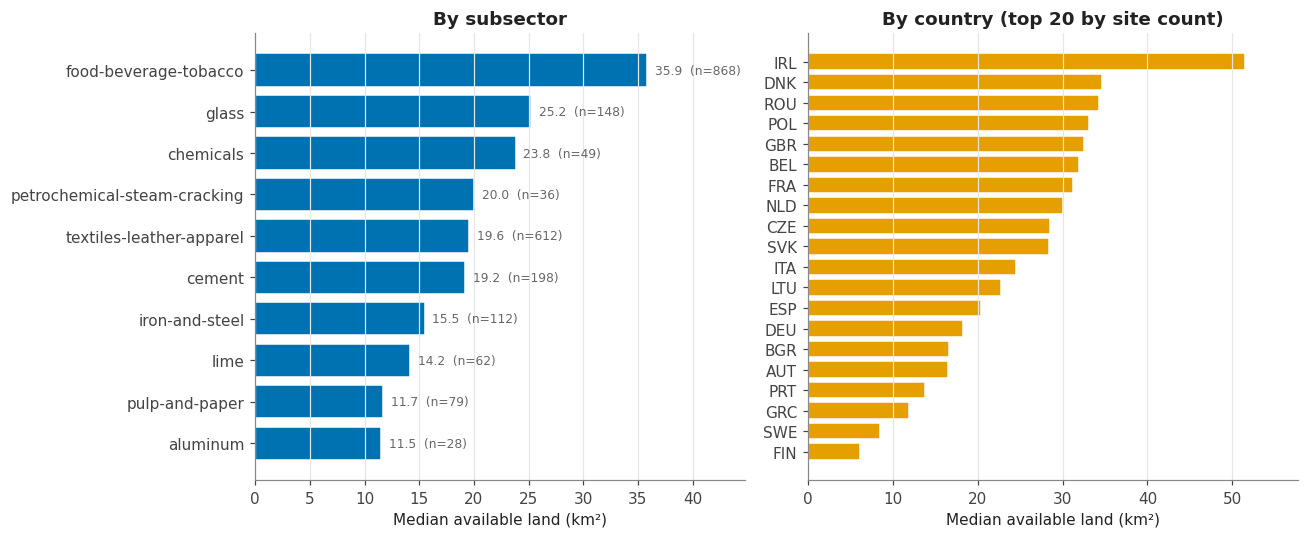

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# by subsector
bs = run.groupby("subsector")["available_land_km2"].agg(["median", "count"]).sort_values("median")
axes[0].barh(bs.index, bs["median"], color="#0072B2", edgecolor="white")
for i, (m, n) in enumerate(zip(bs["median"], bs["count"])):
    axes[0].annotate(f"{m:,.1f}  (n={int(n)})", (m, i), xytext=(5, 0), textcoords="offset points",
                     va="center", fontsize=8, color=MUTED)
axes[0].set_xlabel("Median available land (km²)"); axes[0].set_title("By subsector")
axes[0].margins(x=0.25); axes[0].grid(False, axis="y")

# by country (top 20 by count)
top = run["iso3_country"].value_counts().head(20).index
bc = (run[run["iso3_country"].isin(top)].groupby("iso3_country")["available_land_km2"]
      .median().sort_values())
axes[1].barh(bc.index, bc.values, color="#E69F00", edgecolor="white")
axes[1].set_xlabel("Median available land (km²)"); axes[1].set_title("By country (top 20 by site count)")
axes[1].margins(x=0.12); axes[1].grid(False, axis="y")
plt.tight_layout(); plt.show()


## 6. Geographic pattern

Available land per facility across Europe. Expect more open developable land in agricultural plains (Iberia, France, Poland, Hungary) and less at dense urban / alpine / heavily-forested Nordic sites.

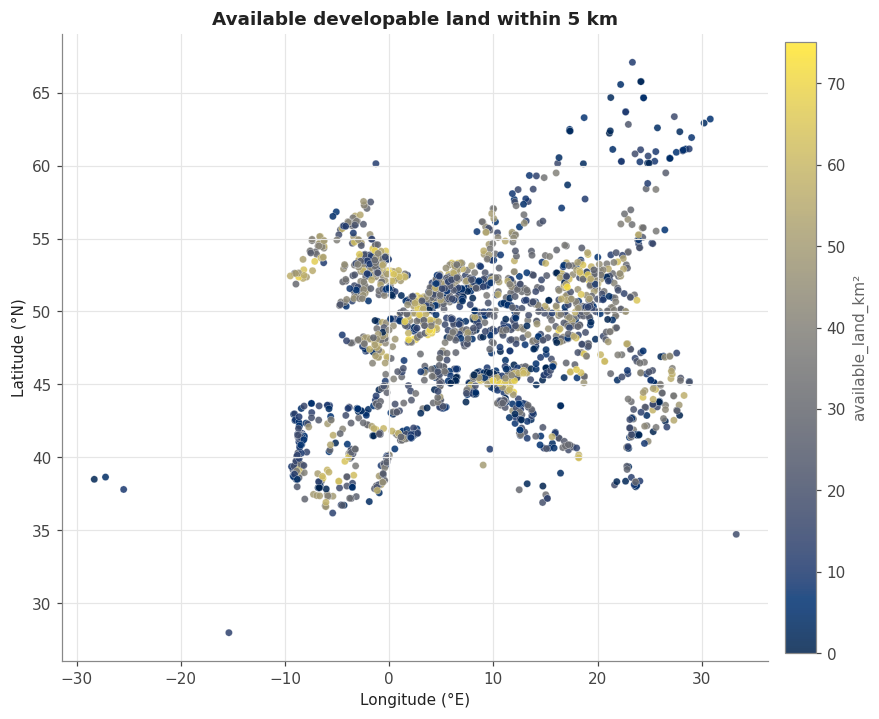

In [7]:
g = df[df["available_land_km2"].notna()]
fig, ax = plt.subplots(figsize=(8.5, 7))
sc = ax.scatter(g["lon"], g["lat"], c=g["available_land_km2"], cmap=SEQ,
                s=22, alpha=0.85, edgecolor="white", linewidth=0.2, vmin=0)
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title("Available developable land within 5 km")
ax.set_aspect(1.4)
cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85); cb.set_label("available_land_km²", color=MUTED)
plt.tight_layout(); plt.show()


## 7. 5 km vs 15 km sensitivity

Available land should scale roughly with buffer area (15²/5² = **9×**) in aggregate; per-facility ratios above 9 are expected where a site is hemmed in at 5 km but its 15 km ring reaches open land.

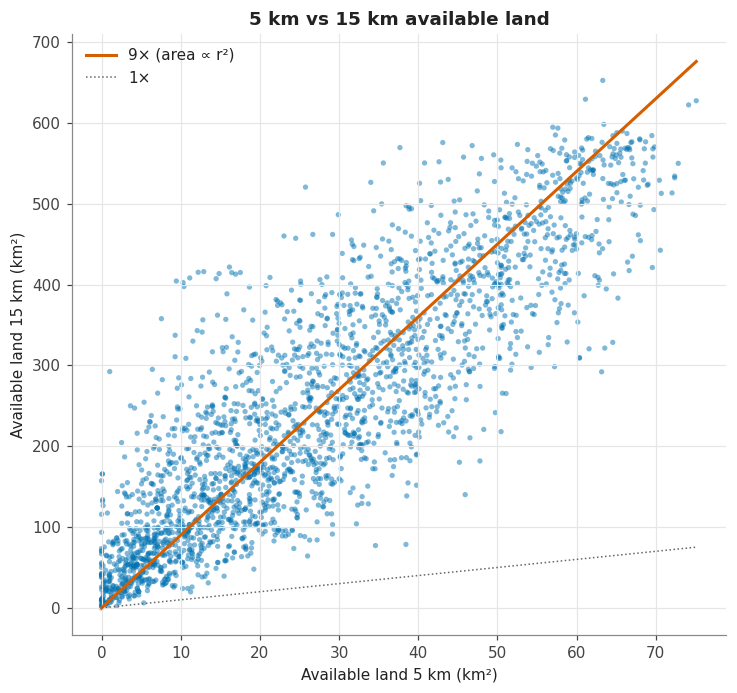

fleet total  5 km: 65,752 km²   15 km: 596,728 km²   ratio: 9.08  (≈9)
per-facility 15/5 ratio  median: 8.92


In [8]:
land15 = pd.read_csv(LAND15)[["source_id", "available_land_km2"]].rename(
    columns={"available_land_km2": "avail_15km"})
cmp = df[["source_id", "available_land_km2"]].rename(columns={"available_land_km2": "avail_5km"}).merge(
    land15, on="source_id")

fig, ax = plt.subplots(figsize=(6.8, 6.4))
ax.scatter(cmp["avail_5km"], cmp["avail_15km"], s=12, alpha=0.5, color="#0072B2", edgecolor="none")
hi = cmp["avail_5km"].max()
ax.plot([0, hi], [0, hi*9], color="#D55E00", lw=2, label="9× (area ∝ r²)")
ax.plot([0, hi], [0, hi], color=MUTED, lw=1, ls=":", label="1×")
ax.set_xlabel("Available land 5 km (km²)"); ax.set_ylabel("Available land 15 km (km²)")
ax.set_title("5 km vs 15 km available land")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

tot5, tot15 = cmp["avail_5km"].sum(), cmp["avail_15km"].sum()
print(f"fleet total  5 km: {tot5:,.0f} km²   15 km: {tot15:,.0f} km²   ratio: {tot15/tot5:.2f}  (≈9)")
print(f"per-facility 15/5 ratio  median: {(cmp['avail_15km']/cmp['avail_5km'].replace(0, np.nan)).median():.2f}")


## 8. Land vs heat demand — is there enough land where it's needed?

The optimization sizes solar against each site's replaceable heat, capped by available land. A rough feasibility read: available land vs replaceable heat, flagging the land-starved high-demand sites (bottom-right).

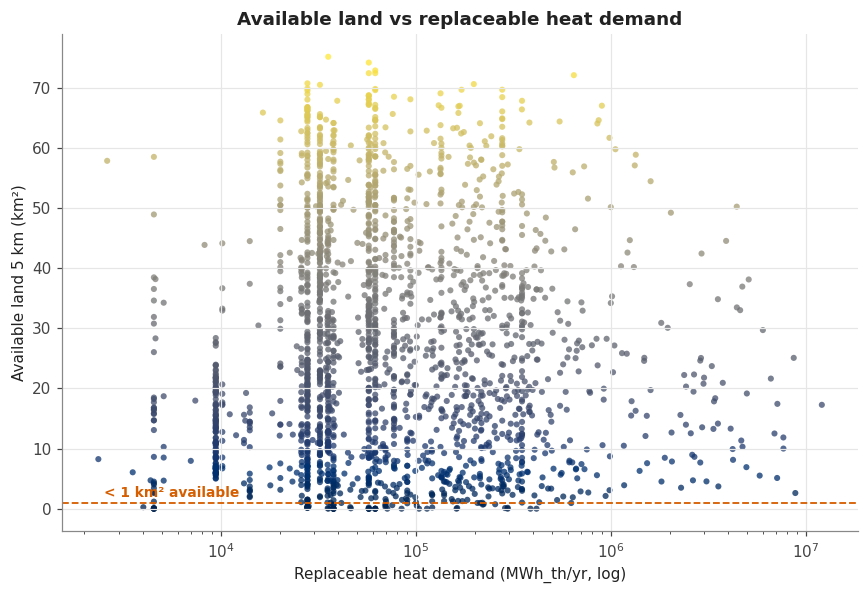

runnable sites with < 1 km² developable land: 64 of 2192 (2.9%)
subsector
textiles-leather-apparel    18
food-beverage-tobacco       17
cement                       9
lime                         6
pulp-and-paper               6
glass                        3
aluminum                     2
iron-and-steel               2
chemicals                    1


In [9]:
r = run[(run["replaceable_heat_mwh_th"] > 0)]
fig, ax = plt.subplots(figsize=(8, 5.5))
sc = ax.scatter(r["replaceable_heat_mwh_th"], r["available_land_km2"],
                c=r["available_land_km2"], cmap=SEQ, s=16, alpha=0.75, edgecolor="none", vmin=0)
ax.set_xscale("log")
ax.set_xlabel("Replaceable heat demand (MWh_th/yr, log)"); ax.set_ylabel("Available land 5 km (km²)")
ax.set_title("Available land vs replaceable heat demand")
ax.axhline(1.0, color="#D55E00", ls="--", lw=1.2)
ax.annotate("< 1 km² available", (r["replaceable_heat_mwh_th"].min(), 1.0), xytext=(4, 4),
            textcoords="offset points", color="#D55E00", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

starved = r[r["available_land_km2"] < 1.0]
print(f"runnable sites with < 1 km² developable land: {len(starved)} of {len(r)} "
      f"({len(starved)/len(r)*100:.1f}%)")
print(starved.groupby("subsector").size().sort_values(ascending=False).to_string())


## 9. Verification summary

Fill in after running:

- **Completeness** — all facilities carry land data; no negative areas; nothing exceeds the 78.5 km² disc.
- **Buffer coverage** — classified + masked ≈ disc; coastal/border sites fall short as expected.
- **Composition** — developable / excluded-cover / slope+protected split is physically sensible.
- **Distribution** — available land and developable share span a plausible range; 26 zero-land sites flagged.
- **Subsector / country / geography** — patterns match intuition (agri plains high, urban/alpine/forest low).
- **5 km vs 15 km** — aggregate ratio ≈ 9× (area ∝ r²); high per-site ratios explained by local geography.
- **Land vs heat** — land-starved high-demand sites identified for the optimizer to handle.
